# Computer Vision: from pixels to convolutional networks

As always we start by getting the correct libararies and setting up our work enviorment.
Its important to do that at the start for consistent results

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
print(f"PyTorch: {torch.__version__}")
print(f"Using:   {device}")

PyTorch: 2.13.0+cu130
Using:   cuda


## Images are tensors

A grayscale image can be stored as a grid of numbers. A color image uses three grids: one each for red, green, and blue. PyTorch orders these dimensions as:

```text
channels x height x width
```

`ToTensor()` converts an image to this format and scales ordinary pixel values from 0-255 to floating-point values from 0-1.

# MNIST: handwritten digits

MNIST is a basic dataset we give to beginners for ML. It is hand written digits in black and white in the exact same background and size.
Its not very representative of real world data that comes dirty, since someone has already cleaned it for us.

We will seperate out a train and test set, so that we can see how well the model is doing. 
If you recall notebook 1 it its important to find metrics that makes sense, data science requires us to think in terms of statistics.

Since no digit is unique in any way, accuracy would be a fine metric, we would ideally like something like 70% or more.
Note that accuracy of even just 30% is much better than random. Since there are 10 digits a random model will give us 10% accuracy (the classes are fairly balanced).

In [2]:
mnist_train = datasets.MNIST(
    root="data", train=True, download=True, transform=transforms.ToTensor()
)
mnist_test = datasets.MNIST(
    root="data", train=False, download=True, transform=transforms.ToTensor()
)

image, label = mnist_train[0]
print(f"Training images: {len(mnist_train):,}")
print(f"Test images:     {len(mnist_test):,}")
print(f"One image shape: {image.shape}")
print(f"Pixel range:     {image.min().item():.1f} to {image.max().item():.1f}")
print(f"Label:           {label}")

Training images: 60,000
Test images:     10,000
One image shape: torch.Size([1, 28, 28])
Pixel range:     0.0 to 1.0
Label:           5


/home/user/Desktop/guy-work/Intro-to-practical-AI-course/3. Computer Vision/.venv/lib/python3.12/site-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/home/user/Desktop/guy-work/Intro-to-practical-AI-course/3. Computer Vision/.venv/lib/python3.12/site-packages/torchvision/datasets/mnist.py:71: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")


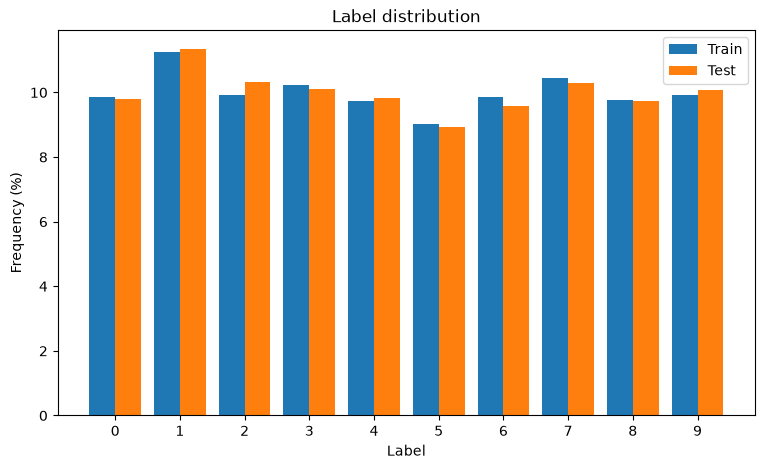

In [3]:
def plot_label_distribution(train, test):
    train_p = torch.bincount(train) / train.numel() * 100
    test_p = torch.bincount(test) / test.numel() * 100

    labels = torch.arange(len(train_p))
    width = 0.4

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(labels - width / 2, train_p, width, label="Train")
    ax.bar(labels + width / 2, test_p, width, label="Test")

    ax.set(
        title="Label distribution",
        xlabel="Label",
        ylabel="Frequency (%)",
        xticks=labels,
    )

    ax.legend()
    plt.show()


plot_label_distribution(
    mnist_train.train_labels,
    mnist_test.test_labels,
)

Even though we did some statistics that doesnt really help us get a feel for what we are wroking with.
Or even that the data is vaugely correct, this time around we didnt build the pipeline.

but you could imagine all sorts of bugs happening when preparing our data.
so its a good idea to specifically take the images and look at them, to get a general idea what we are dealing with

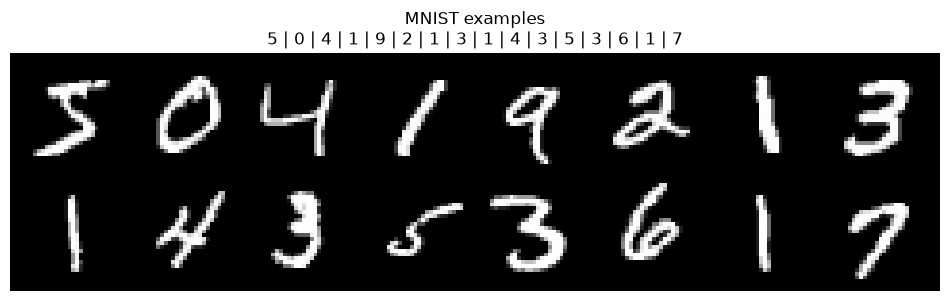

In [4]:
def show_images(images, labels, class_names, title, mean=None, std=None):
    images = images[:16].cpu()
    if mean is not None and std is not None:
        mean = torch.tensor(mean).reshape(-1, 1, 1)
        std = torch.tensor(std).reshape(-1, 1, 1)
        images = images * std + mean

    grid = make_grid(images, nrow=8, padding=2)
    figure, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(grid.permute(1, 2, 0).clip(0, 1), cmap="gray")
    ax.set_title(title + "\n" + " | ".join(class_names[int(label)] for label in labels[:16]))
    ax.axis("off")
    plt.show()

sample_images = torch.stack([mnist_train[index][0] for index in range(16)])
sample_labels = [mnist_train[index][1] for index in range(16)]
show_images(sample_images, sample_labels, [str(number) for number in range(10)], "MNIST examples")

## Batches

A `DataLoader` shuffles the training set and groups examples into batches. The model sees 256 images, updates its weights, and repeats. A batch is much more efficient on a GPU than processing one image at a time.

The test set is not shuffled because it is only used for measurement.

In [5]:
BATCH_SIZE = 256
loader_options = {"batch_size": BATCH_SIZE}

mnist_train_loader = DataLoader(mnist_train, shuffle=True, **loader_options)
mnist_test_loader = DataLoader(mnist_test, shuffle=False, **loader_options)

batch_images, batch_labels = next(iter(mnist_train_loader))
print(f"Image batch: {batch_images.shape}")
print(f"Label batch: {batch_labels.shape}")

Image batch: torch.Size([256, 1, 28, 28])
Label batch: torch.Size([256])


## First model: flatten the image

The models from the previous lesson expect a row of features, not a grid. `Flatten` turns each 1 x 28 x 28 image into 784 pixel values. From there we can use the same techniques we used in our previous leasson, its a simple deep model with 2 layers.

In [6]:
mnist_mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print(mnist_mlp)
print(f"Trainable parameters: {count_parameters(mnist_mlp):,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)
Trainable parameters: 101,770


## Training and evaluation

Each training batch follows the same five steps introduced previously:

1. Run the model to get predictions.
2. Measure the loss.
3. Clear old gradients.
4. Calculate new gradients with `backward()`.
5. Update the parameters.

Evaluation uses `model.eval()` and does not calculate gradients. This makes it faster and prevents evaluation from changing the model.
Note that `eval` and `train` are diffrent from computing gradients. 

Some deep learning techniques work diffrently depending on if we are training or not. We will see this later with batchnorm

In [7]:
loss_function = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = loss_function(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples

@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        total_loss += loss_function(logits, labels).item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples

def fit(model, train_loader, test_loader, epochs, learning_rate=1e-3):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_accuracy = evaluate(model, test_loader)
        history.append((train_loss, train_accuracy, test_loss, test_accuracy))
        print(
            f"epoch {epoch:>2}/{epochs} | "
            f"train loss {train_loss:.3f}, accuracy {train_accuracy:.1%} | "
            f"test loss {test_loss:.3f}, accuracy {test_accuracy:.1%}"
        )

    return history

In [8]:
mnist_history = fit(mnist_mlp, mnist_train_loader, mnist_test_loader, epochs=3)

  0%|          | 0/235 [00:00<?, ?it/s]

epoch  1/3 | train loss 0.515, accuracy 87.3% | test loss 0.265, accuracy 92.5%


  0%|          | 0/235 [00:00<?, ?it/s]

epoch  2/3 | train loss 0.232, accuracy 93.5% | test loss 0.198, accuracy 94.2%


  0%|          | 0/235 [00:00<?, ?it/s]

epoch  3/3 | train loss 0.175, accuracy 95.0% | test loss 0.155, accuracy 95.4%


A small flattened network normally exceeds 95% test accuracy after only three epochs. MNIST is relatively forgiving: the images are centered, grayscale, and almost every pixel belongs to the digit or the empty background.

This result gives us a useful baseline, but it does **not** show that flattening is a good general solution for images.

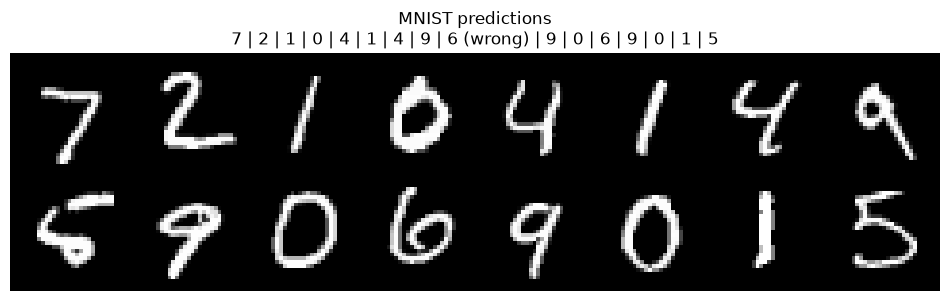

In [9]:
@torch.inference_mode()
def show_predictions(model, loader, class_names, title, mean=None, std=None):
    model.eval()
    images, labels = next(iter(loader))
    predictions = model(images.to(device)).argmax(dim=1).cpu()
    prediction_names = [
        f"{class_names[int(prediction)]}{'' if prediction == label else ' (wrong)'}"
        for prediction, label in zip(predictions[:16], labels[:16])
    ]
    show_images(images, range(16), prediction_names, title, mean, std)

show_predictions(mnist_mlp, mnist_test_loader, [str(number) for number in range(10)], "MNIST predictions")

# CIFAR-10: small color photographs

CIFAR-10 contains 32 x 32 color photographs from ten classes. It has 50,000 training images and 10,000 test images. The image dimensions are still small, but the problem is harder:

- Objects can appear in different positions and at different angles.
- Background pixels are not simply empty.
- Color and local textures matter.
- Several classes have similar shapes, such as cats and dogs or cars and trucks.

## Normalizing color channels

We normalize each red, green, and blue channel using CIFAR-10's approximate mean and standard deviation. This puts the inputs on a friendlier scale for optimization. The test set receives exactly the same normalization as the training set.

In [12]:
#these values are public so we can save time
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

cifar_train = datasets.CIFAR10(root="data", train=True, download=True, transform=cifar_transform)
cifar_test = datasets.CIFAR10(root="data", train=False, download=True, transform=cifar_transform)
cifar_classes = cifar_train.classes

image, label = cifar_train[0]
print(f"Training images: {len(cifar_train):,}")
print(f"Test images:     {len(cifar_test):,}")
print(f"One image shape: {image.shape}")
print(f"Classes:         {cifar_classes}")

Training images: 50,000
Test images:     10,000
One image shape: torch.Size([3, 32, 32])
Classes:         ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


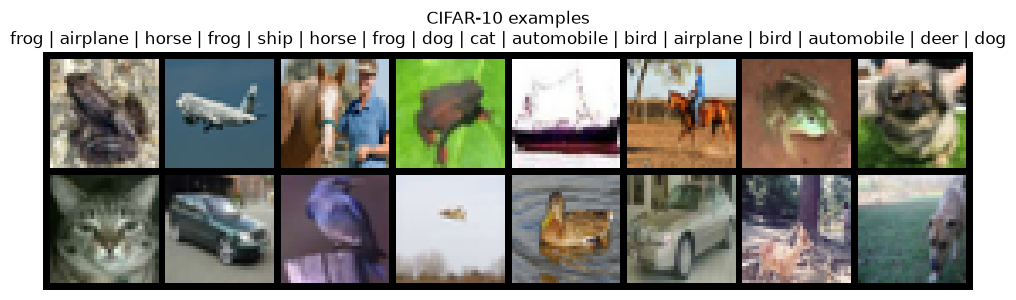

In [13]:
cifar_train_loader = DataLoader(cifar_train, shuffle=True, **loader_options)
cifar_test_loader = DataLoader(cifar_test, shuffle=False, **loader_options)

cifar_images, cifar_labels = next(iter(cifar_train_loader))
show_images(
    cifar_images, cifar_labels, cifar_classes, "CIFAR-10 examples", CIFAR_MEAN, CIFAR_STD
)

In [14]:
#Try and use dir(Object) to find the relvent field in order to print the target labels

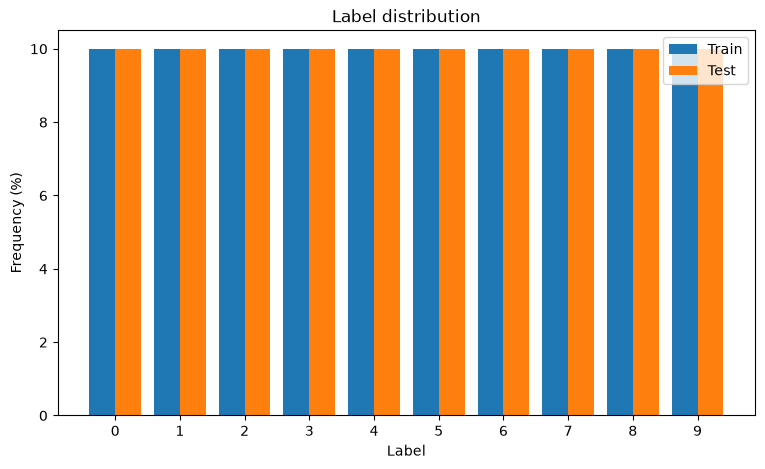

In [15]:
plot_label_distribution(
    torch.IntTensor(cifar_train.targets),
    torch.IntTensor(cifar_test.targets),
)

## First attempt: flatten again

Let us apply the successful MNIST recipe before introducing anything new. A CIFAR-10 image becomes `3 x 32 x 32 = 3,072` unrelated-looking inputs after flattening.

This network is wider than the MNIST network to give the idea a fair chance. Notice the cost: every one of the 3,072 pixels connects to every one of the 512 first-layer neurons. Almost all the parameters are spent in that one layer.

In [16]:
torch.manual_seed(SEED)
cifar_mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * 32 * 32, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10),
)

print(cifar_mlp)
print(f"Trainable parameters: {count_parameters(cifar_mlp):,}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Linear(in_features=256, out_features=10, bias=True)
)
Trainable parameters: 1,707,274


In [17]:
cifar_mlp_history = fit(cifar_mlp, cifar_train_loader, cifar_test_loader, epochs=8)

  0%|          | 0/196 [00:00<?, ?it/s]

epoch  1/8 | train loss 1.648, accuracy 41.9% | test loss 1.515, accuracy 46.2%


  0%|          | 0/196 [00:00<?, ?it/s]

epoch  2/8 | train loss 1.421, accuracy 50.0% | test loss 1.417, accuracy 50.0%


  0%|          | 0/196 [00:00<?, ?it/s]

...

epoch  6/8 | train loss 1.050, accuracy 63.1% | test loss 1.366, accuracy 53.2%


  0%|          | 0/196 [00:00<?, ?it/s]

epoch  7/8 | train loss 0.981, accuracy 65.4% | test loss 1.367, accuracy 54.4%


  0%|          | 0/196 [00:00<?, ?it/s]

epoch  8/8 | train loss 0.897, accuracy 68.5% | test loss 1.414, accuracy 53.5%


Unlike MNIST, this model will commonly finish around 45-55% test accuracy. That is better than random guessing at 10%, but nowhere near its MNIST result. You may also see training accuracy continue to rise while test accuracy stalls. This gap is **overfitting**: the model is learning details of the training examples that do not generalize well.

Flattening has destroyed an important fact: nearby pixels are related. It also treats an object shifted one pixel to the right as an entirely new arrangement of inputs. Adding more dense neurons increases the parameter count without fixing either problem.

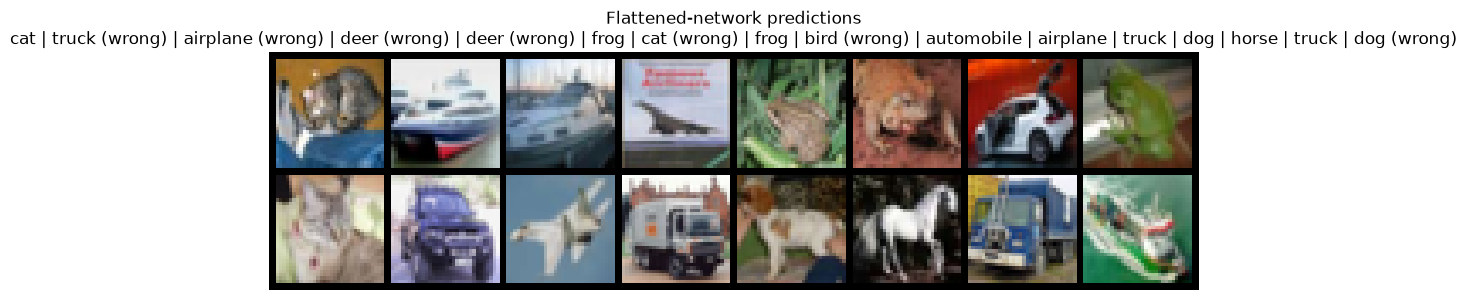

In [18]:
show_predictions(
    cifar_mlp, cifar_test_loader, cifar_classes, "Flattened-network predictions", CIFAR_MEAN, CIFAR_STD
)

# Convolutional neural networks

## Conv2d
A convolutional layer learns small filters and slides each filter across the image. A 3 x 3 filter examines neighboring pixels, so it can learn local patterns such as edges, corners, and textures. This means that we can run on the entire image using less than 100 weights total.
It is also much faster on GPU since there is far fewer weights to multiply.

Conv nets used to be a huge deal, altogh since 2017~2020 we are slowly phasing them out in favor of transformers. The relvent paper is VIT for those who are intrested. 


## BatchNorm
batch norm normalizes the network activations over an entire batch during training.

during infrence we use our best guess for the entire distribution based on a runing avrage of the training activations.
This is why this layer works diffrently in `train()` and `eval()`

## MaxPool2d
We want to take the output of the network and make it have lower and lower resolution over time.
If you recall from the previous leasson models typically work well if their last few layers are narrower.

max pool simply takes an entire chunk of a 2x2 and returns only the maximal value for that entire region.
So it would cut the image size by 4.

## AvgPool2d
This layer works the same as maxpool but with an avrage.

In [19]:
torch.manual_seed(SEED)
cifar_cnn = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),                 # 32 x 16 x 16

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),                 # 64 x 8 x 8

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.AvgPool2d(8),          # 128 x 1 x 1
    nn.Flatten(),
    nn.Linear(128, 10),
)

mlp_parameters = count_parameters(cifar_mlp)
cnn_parameters = count_parameters(cifar_cnn)
print(cifar_cnn)
print(f"Flattened network: {mlp_parameters:,} parameters")
print(f"CNN:               {cnn_parameters:,} parameters")
print(f"The CNN is {mlp_parameters / cnn_parameters:.1f}x smaller.")

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (10): ReLU()
  (11): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=128, out_features=10, bias=True)
)
Flattened network: 1,707,274 parameters
CNN:               94,986 parameters
The CNN is 18.0x smaller.


Before training, verify that the dimensions flow through the model as expected. The batch dimension remains 256 and the final output contains ten class scores per image.

In [20]:
example_batch = cifar_images[:4]
current = example_batch
for layer in cifar_cnn:
    current = layer(current)
    print(f"{layer.__class__.__name__:>18}: {tuple(current.shape)}")

            Conv2d: (4, 32, 32, 32)
       BatchNorm2d: (4, 32, 32, 32)
              ReLU: (4, 32, 32, 32)
         MaxPool2d: (4, 32, 16, 16)
            Conv2d: (4, 64, 16, 16)
       BatchNorm2d: (4, 64, 16, 16)
              ReLU: (4, 64, 16, 16)
         MaxPool2d: (4, 64, 8, 8)
            Conv2d: (4, 128, 8, 8)
       BatchNorm2d: (4, 128, 8, 8)
              ReLU: (4, 128, 8, 8)
         AvgPool2d: (4, 128, 1, 1)
           Flatten: (4, 128)
            Linear: (4, 10)


In [21]:
cifar_cnn_history = fit(cifar_cnn, cifar_train_loader, cifar_test_loader, epochs=12)

  0%|          | 0/196 [00:00<?, ?it/s]

epoch  1/12 | train loss 1.513, accuracy 46.5% | test loss 1.300, accuracy 53.9%


  0%|          | 0/196 [00:00<?, ?it/s]

epoch  2/12 | train loss 1.184, accuracy 58.2% | test loss 1.586, accuracy 49.4%


  0%|          | 0/196 [00:00<?, ?it/s]

...

epoch 10/12 | train loss 0.759, accuracy 73.7% | test loss 0.963, accuracy 66.3%


  0%|          | 0/196 [00:00<?, ?it/s]

epoch 11/12 | train loss 0.727, accuracy 74.9% | test loss 0.914, accuracy 68.5%


  0%|          | 0/196 [00:00<?, ?it/s]

epoch 12/12 | train loss 0.708, accuracy 75.6% | test loss 0.859, accuracy 69.5%


This compact CNN will commonly reach roughly 65-75% test accuracy without data augmentation. It should beat the flattened model despite using around 15-20 times fewer parameters.

The point is not that CNNs magically solve CIFAR-10. The point is that their assumptions match images better:

- Local pixels are processed together.
- Useful filters are shared across positions.
- Pooling makes small shifts less important.
- Later layers build larger patterns from smaller ones.

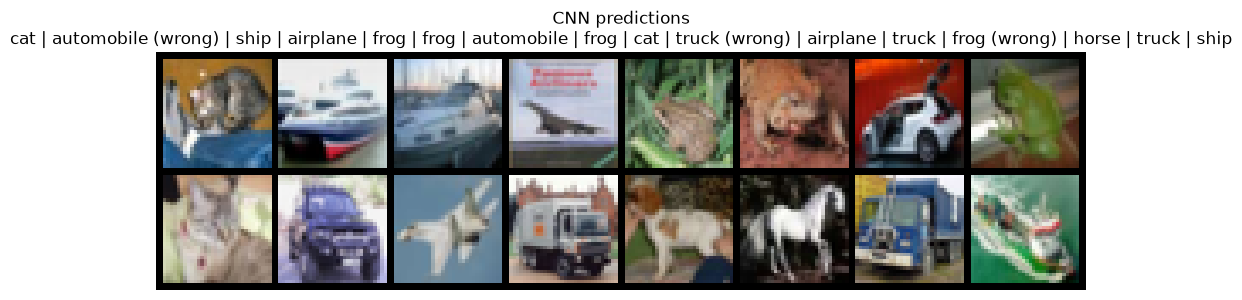

In [22]:
show_predictions(
    cifar_cnn, cifar_test_loader, cifar_classes, "CNN predictions", CIFAR_MEAN, CIFAR_STD
)

## Compare the experiment

We compare test accuracy rather than training accuracy. A classifier is useful when it generalizes to new images, not when it memorizes its training set.

model                    parameters   test accuracy
---------------------------------------------------
flattened network         1,707,274          53.5%
CNN                          94,986          69.5%


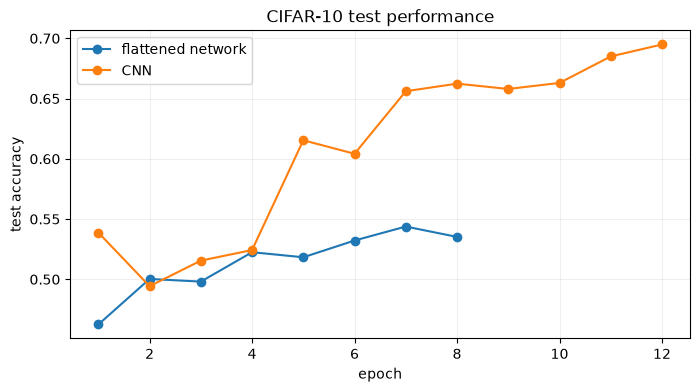

In [23]:
mlp_test_accuracy = cifar_mlp_history[-1][3]
cnn_test_accuracy = cifar_cnn_history[-1][3]

print(f"{'model':<22} {'parameters':>12} {'test accuracy':>15}")
print("-" * 51)
print(f"{'flattened network':<22} {mlp_parameters:>12,} {mlp_test_accuracy:>14.1%}")
print(f"{'CNN':<22} {cnn_parameters:>12,} {cnn_test_accuracy:>14.1%}")

epochs = range(1, len(cifar_cnn_history) + 1)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cifar_mlp_history) + 1), [row[3] for row in cifar_mlp_history], marker="o", label="flattened network")
plt.plot(epochs, [row[3] for row in cifar_cnn_history], marker="o", label="CNN")
plt.xlabel("epoch")
plt.ylabel("test accuracy")
plt.title("CIFAR-10 test performance")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

In [24]:
augmented_transform = transforms.Compose([
    # Add RandomCrop and RandomHorizontalFlip here.
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

augmented_train = datasets.CIFAR10(
    root="data", train=True, download=False, transform=augmented_transform
)
augmented_train_loader = DataLoader(augmented_train, shuffle=True, **loader_options)

Make a fresh CNN by running the model-definition cell again, then train it with `augmented_train_loader`. Compare its test accuracy with `cnn_test_accuracy`.

Questions to consider:

1. Does augmentation lower training accuracy while improving test accuracy? Why can that be healthy?
2. Which CIFAR-10 classes are still commonly confused?
3. Would a vertical flip be a sensible augmentation for cars, ships, and animals?
4. Can you improve test accuracy without making the model larger?

In [ ]:
# Recreate and train your CNN here.
